In [5]:
import pandas as pd
from pycaret.classification import *
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
import optunahub
import optuna

from pycaret.internal.preprocess.transformers import TransformerWrapper

In [6]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')
data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] != gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


## GK


### Base Model


In [ ]:
g_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[g_cs_features]
g_cs_data_tar = g_cs_data_tar[g_cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

clean_sheets
0.0    1206
1.0     369
Name: count, dtype: int64


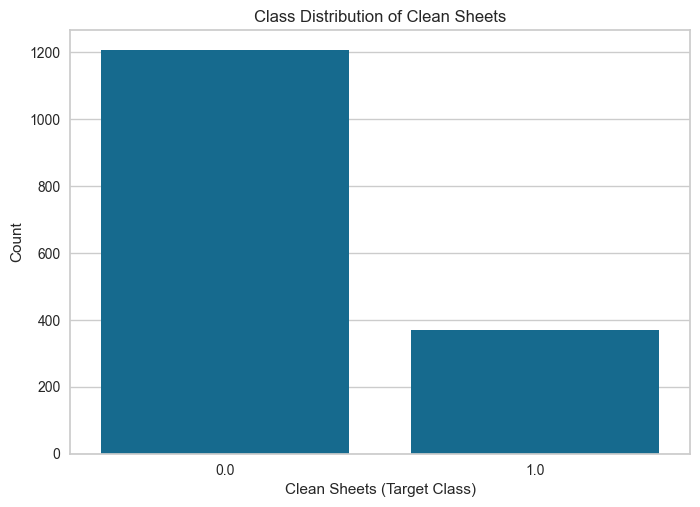

In [ ]:
print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

In [ ]:
base_g_cs_model = setup(g_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_cs_best = base_g_cs_model.compare_models(sort='AUC')
base_g_cs_best

[LightGBM] [Info] Number of positive: 965, number of negative: 965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10763
[LightGBM] [Info] Number of data points in the train set: 1930, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,1726
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(2245, 24)"
5,Transformed train set shape,"(1930, 24)"
6,Transformed test set shape,"(315, 24)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.5579,0.5585,0.5021,0.2640,0.3451,0.0574,0.0657,0.4490
lda,Linear Discriminant Analysis,0.5595,0.5557,0.4915,0.2653,0.3439,0.0566,0.0620,0.4230
lr,Logistic Regression,0.5619,0.5531,0.5057,0.2676,0.3488,0.0639,0.0725,1.6520
xgboost,Extreme Gradient Boosting,0.7175,0.5433,0.1425,0.2811,0.1855,0.0413,0.0439,0.6040
rf,Random Forest Classifier,0.7246,0.5426,0.0853,0.2305,0.1236,0.0061,0.0040,0.8280
svm,SVM - Linear Kernel,0.5294,0.5421,0.4914,0.2437,0.3243,0.0212,0.0272,0.6070
knn,K Neighbors Classifier,0.4730,0.5375,0.6243,0.2496,0.3564,0.0332,0.0439,0.7060
nb,Naive Bayes,0.4817,0.5340,0.5867,0.2449,0.3443,0.0236,0.0315,0.5080
lightgbm,Light Gradient Boosting Machine,0.7198,0.5295,0.0989,0.2513,0.1392,0.0108,0.0125,0.8280
qda,Quadratic Discriminant Analysis,0.5492,0.5284,0.4174,0.2354,0.2990,0.0041,0.0058,0.5650


RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=1726, solver='auto',
                tol=0.0001)

In [ ]:
evaluate_model(base_g_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

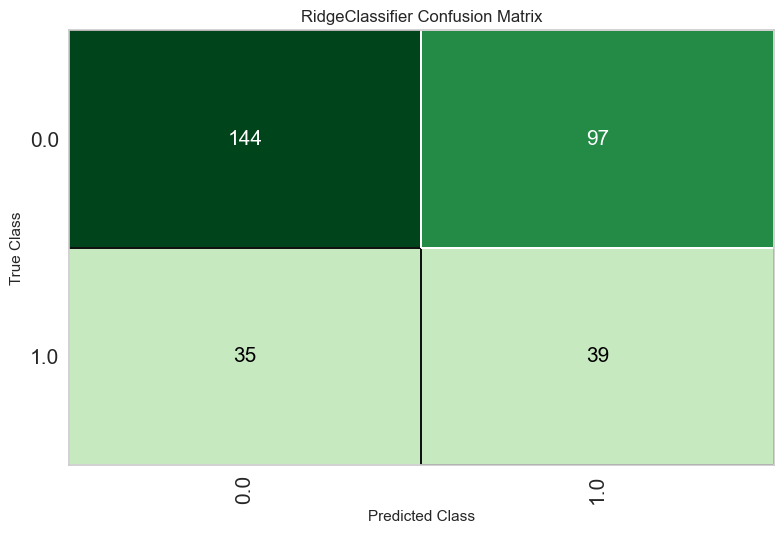

In [ ]:
plot_model(base_g_cs_best, plot='confusion_matrix')

### Tuned Model


In [ ]:
# Enhanced setup for better performance
tuned_g_cs_model = setup(g_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_cs_best = tuned_g_cs_model.compare_models(n_select=3, sort='F1')
g_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(832, 59)"
5,Transformed train set shape,"(517, 59)"
6,Transformed test set shape,"(315, 59)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.5127,0.5330,0.5692,0.2568,0.3537,0.0457,0.0547,0.3660
qda,Quadratic Discriminant Analysis,0.3341,0.5109,0.8110,0.2327,0.3450,0.0012,-0.0129,0.2960
dt,Decision Tree Classifier,0.6167,0.5473,0.4170,0.2862,0.3375,0.0828,0.0856,0.4340
lr,Logistic Regression,0.5738,0.5283,0.4443,0.2606,0.3263,0.0465,0.0504,0.5510
lda,Linear Discriminant Analysis,0.5786,0.5291,0.4002,0.2513,0.3081,0.0286,0.0296,0.2590
svm,SVM - Linear Kernel,0.5579,0.5052,0.4264,0.2435,0.3070,0.0181,0.0206,0.2950
ridge,Ridge Classifier,0.5778,0.5276,0.3829,0.2442,0.2962,0.0166,0.0178,0.3290
xgboost,Extreme Gradient Boosting,0.6825,0.5835,0.2883,0.3032,0.2933,0.0911,0.0910,0.4090
ada,Ada Boost Classifier,0.6246,0.5222,0.3286,0.2594,0.2872,0.0391,0.0400,0.3870
nb,Naive Bayes,0.4675,0.5204,0.5690,0.2422,0.2811,0.0087,0.0021,0.4150


[KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                      metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                      weights='uniform'),
 QuadraticDiscriminantAnalysis(priors=None, reg_param=0.0,
                               store_covariance=False, tol=0.0001),
 DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                        max_depth=None, max_features=None, max_leaf_nodes=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, random_state=123, splitter='best')]

In [ ]:
# Ensemble (blend or stack)
g_cs_blended = blend_models(g_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4365,0.5020,0.5172,0.2083,0.2970,-0.0463,-0.0599
1,0.4127,0.4881,0.6552,0.2289,0.3393,-0.0028,-0.0041
2,0.4127,0.5192,0.6897,0.2353,0.3509,0.0117,0.0176
3,0.4048,0.5371,0.7241,0.2386,0.3590,0.0195,0.0306
4,0.4524,0.4762,0.6897,0.2500,0.3670,0.0440,0.0622
5,0.6190,0.5116,0.2333,0.2188,0.2258,-0.0265,-0.0265
6,0.5635,0.4889,0.1667,0.1429,0.1538,-0.1379,-0.1387
7,0.6587,0.5896,0.4000,0.3243,0.3582,0.1292,0.1305
8,0.7222,0.5597,0.3333,0.4000,0.3636,0.1878,0.1891


In [ ]:
g_cs_tuned = tune_model(g_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3968,0.4440,0.6207,0.2169,0.3214,-0.0299,-0.0439
1,0.4365,0.4595,0.6207,0.2308,0.3364,0.0013,0.0018
2,0.5000,0.5990,0.7241,0.2763,0.4000,0.1002,0.1352
3,0.4841,0.5986,0.8276,0.2857,0.4248,0.1256,0.1867
4,0.4524,0.5811,0.7586,0.2619,0.3894,0.0717,0.1067
5,0.5476,0.6231,0.8000,0.3200,0.4571,0.1773,0.2332
6,0.4365,0.4814,0.7000,0.2530,0.3717,0.0337,0.0487
7,0.5397,0.6021,0.6667,0.2941,0.4082,0.1161,0.1424
8,0.6587,0.5179,0.1333,0.1905,0.1569,-0.0488,-0.0500


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

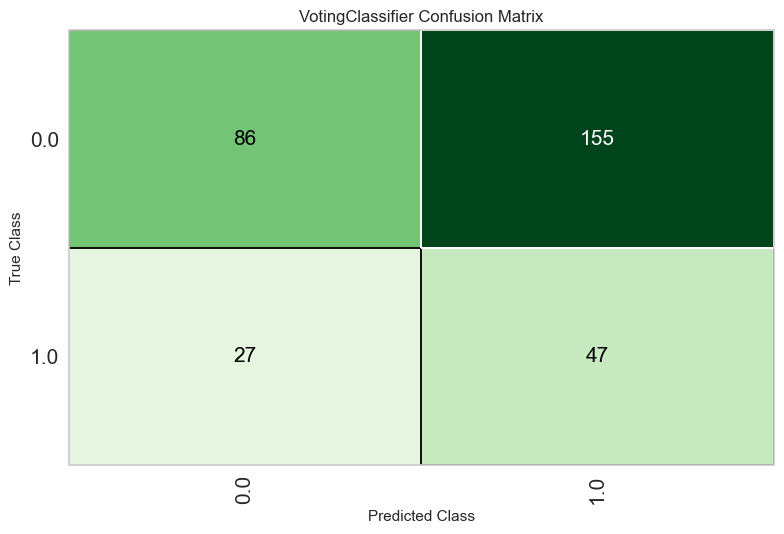

In [ ]:
plot_model(g_cs_tuned, plot='confusion_matrix')

In [ ]:
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_cs_tuned, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.4222,0.5382,0.6351,0.2327,0.3406,-0.0050,-0.0071


In [ ]:
# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [ ]:
evaluate_model(g_cs_tuned)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [ ]:
g_cs_final_model = finalize_model(g_cs_tuned)


In [ ]:
save_model(g_cs_final_model, 'g_cs_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                       criterion='gini',
             

## Def


In [6]:
d_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[d_cs_features]
def_cs_data_tar = def_cs_data_tar[d_cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0.0    5054
1.0    1401
Name: count, dtype: int64


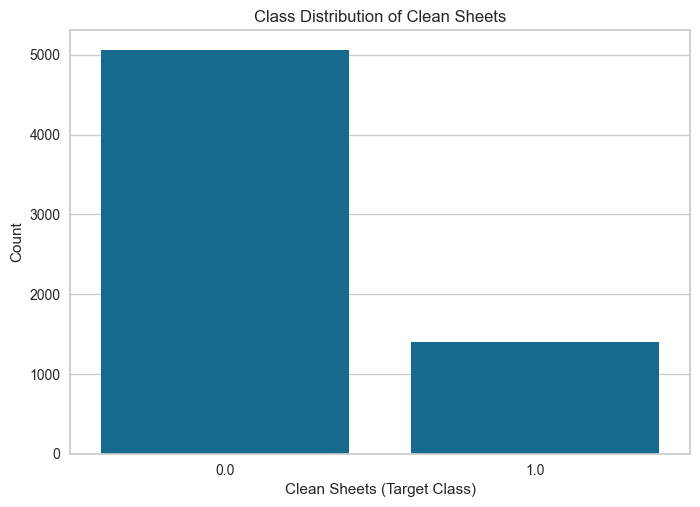

In [7]:
print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [8]:
base_def_cs_model = setup(def_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_cs_best = base_def_cs_model.compare_models(sort='AUC')
base_def_cs_best

[LightGBM] [Info] Number of positive: 4043, number of negative: 4043
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011607 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17100
[LightGBM] [Info] Number of data points in the train set: 8086, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,8781
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(9377, 24)"
5,Transformed train set shape,"(8086, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8757,0.8814,0.5245,0.8447,0.6458,0.5756,0.6003,1.7400
rf,Random Forest Classifier,0.8571,0.8566,0.3836,0.9047,0.5373,0.4689,0.5301,2.0550
xgboost,Extreme Gradient Boosting,0.8395,0.8279,0.4032,0.7419,0.5211,0.4348,0.4647,1.3220
lightgbm,Light Gradient Boosting Machine,0.8224,0.8109,0.2632,0.7613,0.3900,0.3145,0.3757,1.3470
knn,K Neighbors Classifier,0.6168,0.7583,0.7886,0.3368,0.4718,0.2409,0.2953,1.0690
gbc,Gradient Boosting Classifier,0.7825,0.6766,0.0437,0.5096,0.0800,0.0463,0.0954,3.6660
dt,Decision Tree Classifier,0.7465,0.6441,0.4630,0.4231,0.4415,0.2782,0.2790,0.9150
ada,Ada Boost Classifier,0.7432,0.6255,0.1677,0.3263,0.2200,0.0854,0.0928,1.3760
ridge,Ridge Classifier,0.5962,0.6219,0.5575,0.2823,0.3746,0.1216,0.1371,0.9230
lda,Linear Discriminant Analysis,0.5964,0.6217,0.5405,0.2786,0.3674,0.1137,0.1274,0.9030


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=8781, verbose=0,
                     warm_start=False)

In [9]:
evaluate_model(base_def_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [10]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_def_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8970,0.9287,0.6107,0.8769,0.7200,0.6593,0.6755


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
196,0.565,0.255,0.180,False,2.0,4.0,-4265.0,-0.652711,1.5,15.000000,...,1.6,1.6,2.0,0.06,0.06,2.08,1.0,0,0.70,0.30
5806,NaN,NaN,NaN,True,3.0,1.0,-4055.0,-0.337086,2.0,19.200001,...,1.4,1.6,1.0,0.11,0.11,NaN,0.0,0,0.83,0.17
2454,0.669,0.194,0.137,True,2.0,5.0,166971.0,0.773183,8.8,21.600000,...,1.4,1.8,4.6,0.40,0.28,3.68,0.0,0,0.50,0.50
83,0.693,0.189,0.118,False,3.0,4.0,-6848.0,-0.253521,1.8,14.800000,...,1.0,1.6,3.8,0.34,0.33,4.46,0.0,0,0.85,0.15
3837,0.826,0.111,0.063,False,2.0,5.0,-516.0,-0.671554,1.3,13.000000,...,1.8,1.0,1.0,0.14,0.04,1.10,0.0,0,0.82,0.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5860,0.364,0.272,0.364,True,3.0,1.0,-110.0,-0.122108,8.3,29.000000,...,1.6,1.8,1.6,0.32,0.29,0.34,1.0,1,0.44,0.56
3794,0.154,0.205,0.641,True,4.0,2.0,-62662.0,-0.895589,1.6,11.200000,...,1.8,1.0,2.0,0.14,0.14,2.20,0.0,0,0.88,0.12
3278,0.169,0.222,0.609,True,5.0,2.0,42379.0,0.587313,2.9,12.800000,...,0.8,1.4,5.4,0.21,0.20,4.26,0.0,0,0.68,0.32
4114,0.508,0.224,0.268,True,2.0,4.0,-8028.0,-0.054231,2.7,15.800000,...,2.0,1.2,3.0,0.21,0.20,1.88,0.0,0,0.66,0.34


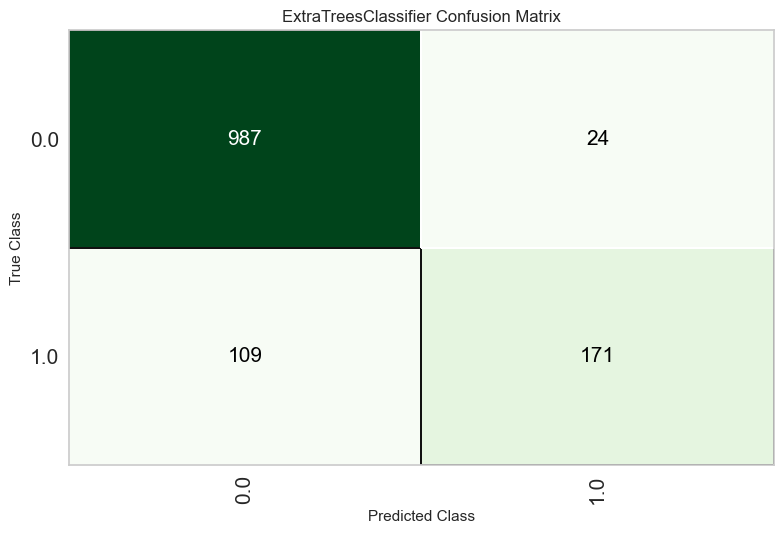

In [11]:
plot_model(base_def_cs_best, plot='confusion_matrix')

In [12]:
base_def_cs_tuned = tune_model(base_def_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7021,0.7012,0.3750,0.3333,0.3529,0.1603,0.1608
1,0.7389,0.6939,0.3482,0.3861,0.3662,0.2023,0.2027
2,0.7369,0.6885,0.4018,0.3947,0.3982,0.2299,0.2299
3,0.7466,0.7158,0.4248,0.4211,0.4229,0.2606,0.2606
4,0.7791,0.7421,0.4018,0.4891,0.4412,0.3051,0.3074
5,0.7190,0.6469,0.2589,0.3187,0.2857,0.1131,0.1141
6,0.7578,0.7407,0.4464,0.4425,0.4444,0.2896,0.2896
7,0.7364,0.6857,0.3304,0.3776,0.3524,0.1879,0.1885
8,0.7539,0.7104,0.3929,0.4272,0.4093,0.2542,0.2546


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [22]:
save_model(base_def_cs_tuned, 'def_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Tuned Model


In [15]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_def_cs_model = setup(def_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_cs_best = tuned_def_cs_model.compare_models(n_select=3, sort='F1')
def_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(4417, 66)"
5,Transformed train set shape,"(3126, 66)"
6,Transformed test set shape,"(1291, 66)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.6919,0.6957,0.4969,0.3505,0.4103,0.2101,0.2167,0.9910
xgboost,Extreme Gradient Boosting,0.7291,0.6956,0.4122,0.3848,0.3977,0.2233,0.2237,1.0890
rf,Random Forest Classifier,0.7093,0.6765,0.4353,0.3605,0.3934,0.2050,0.2070,1.3430
lightgbm,Light Gradient Boosting Machine,0.7273,0.6918,0.4068,0.3796,0.3920,0.2168,0.2174,1.2570
lr,Logistic Regression,0.5068,0.6171,0.7101,0.2636,0.3843,0.0993,0.1347,0.9510
lda,Linear Discriminant Analysis,0.5062,0.6137,0.6976,0.2615,0.3802,0.0942,0.1260,0.7260
ridge,Ridge Classifier,0.4948,0.6116,0.7065,0.2576,0.3774,0.0872,0.1203,0.7160
dt,Decision Tree Classifier,0.6408,0.5901,0.5005,0.3023,0.3765,0.1455,0.1549,0.7490
knn,K Neighbors Classifier,0.4063,0.5894,0.8234,0.2436,0.3759,0.0614,0.1063,0.7890
svm,SVM - Linear Kernel,0.5230,0.5895,0.6164,0.2532,0.3585,0.0742,0.0942,0.6740


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cpu', early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=N

In [16]:
# Ensemble (blend or stack)
def_cs_blended = blend_models(def_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6712,0.5957,0.3304,0.2803,0.3033,0.0900,0.0905
1,0.7466,0.7344,0.3839,0.4095,0.3963,0.2362,0.2364
2,0.7195,0.6920,0.3929,0.3636,0.3777,0.1970,0.1973
3,0.7292,0.7261,0.4690,0.3985,0.4309,0.2548,0.2562
4,0.7597,0.7667,0.5536,0.4559,0.5000,0.3438,0.3466
5,0.7093,0.6645,0.3036,0.3208,0.3119,0.1278,0.1279
6,0.7190,0.7134,0.3839,0.3613,0.3723,0.1915,0.1916
7,0.7519,0.7200,0.5268,0.4403,0.4797,0.3185,0.3207
8,0.7481,0.7207,0.4911,0.4297,0.4583,0.2951,0.2963


In [ ]:
def_cs_tuned = tune_model(def_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6596,0.6063,0.4196,0.2975,0.3481,0.1267,0.1302
1,0.7079,0.7250,0.5179,0.3742,0.4345,0.2444,0.2503
2,0.7060,0.6710,0.4018,0.3462,0.3719,0.1814,0.1822
3,0.7350,0.7145,0.4159,0.3983,0.4069,0.2364,0.2365
4,0.7442,0.7569,0.5000,0.4242,0.4590,0.2930,0.2947
5,0.7093,0.6790,0.4821,0.3699,0.4186,0.2293,0.2328
6,0.7713,0.7270,0.4464,0.4717,0.4587,0.3139,0.3141
7,0.7500,0.7323,0.4643,0.4298,0.4464,0.2852,0.2856
8,0.7248,0.7176,0.4107,0.3770,0.3932,0.2156,0.2160


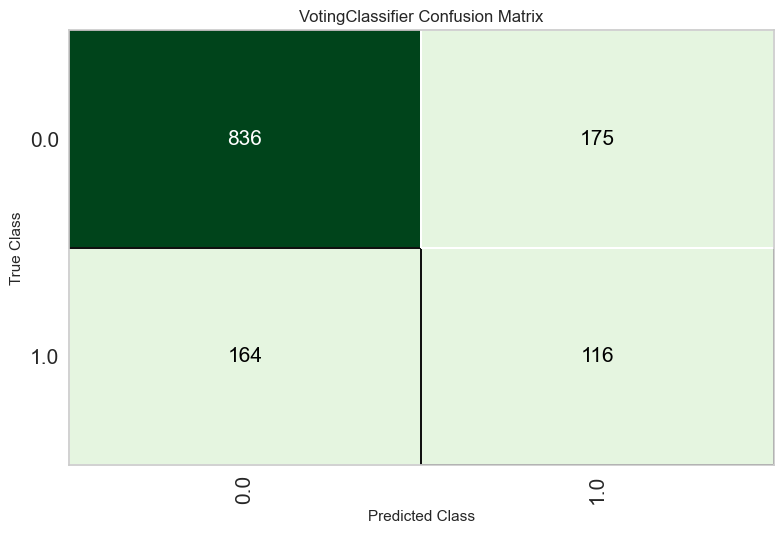

In [ ]:
plot_model(def_cs_tuned, plot='confusion_matrix')

## Mid


In [24]:
mid_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[mid_cs_features]
mid_cs_data_tar = mid_cs_data_tar[mid_cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0.0    5054
1.0    1401
Name: count, dtype: int64


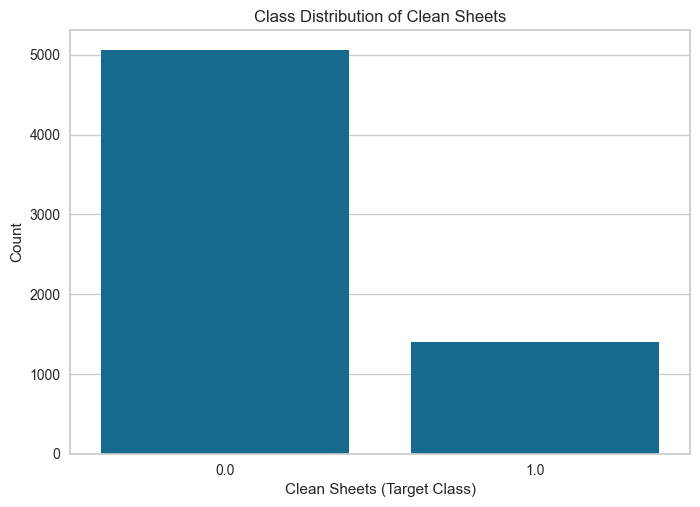

In [25]:
print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base


In [26]:
base_mid_cs_model = setup(mid_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_cs_best = base_mid_cs_model.compare_models(sort='AUC')
base_mid_cs_best

[LightGBM] [Info] Number of positive: 4043, number of negative: 4043
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.032091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16761
[LightGBM] [Info] Number of data points in the train set: 8086, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,8473
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(9377, 24)"
5,Transformed train set shape,"(8086, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8815,0.8947,0.5628,0.8370,0.6720,0.6033,0.6215,1.9860
rf,Random Forest Classifier,0.8594,0.8667,0.4040,0.8871,0.5541,0.4845,0.5378,2.6900
xgboost,Extreme Gradient Boosting,0.8519,0.8398,0.4290,0.7925,0.5557,0.4765,0.5092,1.4710
lightgbm,Light Gradient Boosting Machine,0.8364,0.8283,0.3166,0.8192,0.4539,0.3800,0.4405,2.1860
knn,K Neighbors Classifier,0.6278,0.7645,0.7850,0.3441,0.4782,0.2526,0.3049,1.5630
gbc,Gradient Boosting Classifier,0.7889,0.6967,0.0678,0.6269,0.1211,0.0831,0.1520,4.1040
lda,Linear Discriminant Analysis,0.6059,0.6333,0.5807,0.2939,0.3901,0.1432,0.1614,1.3480
dt,Decision Tree Classifier,0.7304,0.6325,0.4594,0.3972,0.4254,0.2508,0.2523,1.8970
lr,Logistic Regression,0.6042,0.6321,0.5923,0.2947,0.3934,0.1461,0.1661,3.3380
ridge,Ridge Classifier,0.6098,0.6318,0.5986,0.3004,0.3999,0.1558,0.1761,1.3320


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=8473, verbose=0,
                     warm_start=False)

In [27]:
evaluate_model(base_mid_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [31]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_mid_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8939,0.9082,0.6357,0.8357,0.7221,0.6580,0.6674


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
954,0.709,0.180,0.111,True,3.0,5.0,-2542.0,0.317211,1.5,12.000000,...,1.8,2.8,4.8,0.43,0.35,6.74,0.0,0,0.65,0.35
3282,0.337,0.251,0.412,True,3.0,2.0,718.0,-0.003627,4.2,16.600000,...,0.8,1.2,2.6,0.04,0.04,3.84,0.0,0,0.96,0.04
3974,0.495,0.249,0.256,True,5.0,5.0,-53406.0,-0.246862,3.9,5.000000,...,0.8,1.4,4.6,0.83,0.82,4.58,0.0,0,0.60,0.40
4966,0.451,0.296,0.253,True,2.0,3.0,12594.0,0.293614,6.2,21.600000,...,1.6,1.2,2.6,0.10,0.04,NaN,0.0,0,0.81,0.19
4691,0.461,0.252,0.287,True,3.0,3.0,2800.0,0.784508,3.8,24.400000,...,1.4,1.2,5.0,0.65,0.65,NaN,0.0,0,0.70,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4932,0.509,0.286,0.205,False,3.0,3.0,0.0,-0.102825,4.0,39.400002,...,1.4,2.0,4.2,0.43,0.43,4.56,0.0,0,0.80,0.20
5631,0.485,0.237,0.278,False,4.0,4.0,0.0,-0.911356,1.5,14.200000,...,1.8,2.0,1.6,0.06,0.05,2.28,0.0,0,0.74,0.26
1795,0.470,0.261,0.269,False,2.0,2.0,1205.0,0.346919,1.5,12.000000,...,0.6,2.0,3.0,0.11,0.11,2.62,0.0,0,0.66,0.34
4922,0.187,0.234,0.578,True,3.0,3.0,9693.0,0.558493,1.6,15.800000,...,0.0,1.6,5.0,0.10,0.10,3.64,1.0,1,0.15,0.85


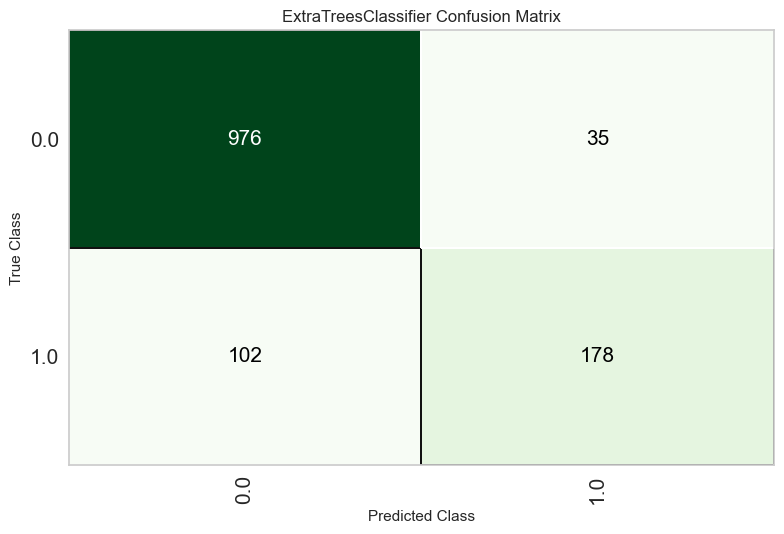

In [32]:

plot_model(base_mid_cs_best, plot='confusion_matrix')

In [40]:
base_mid_cs_tuned = tune_model(base_mid_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4487,0.5682,0.6607,0.2305,0.3418,0.0304,0.0432
1,0.5164,0.6574,0.8482,0.2896,0.4318,0.1608,0.2334
2,0.4874,0.5870,0.6875,0.2508,0.3675,0.0734,0.1003
3,0.4797,0.6838,0.8407,0.2746,0.4139,0.1259,0.1927
4,0.4516,0.7114,0.8929,0.2695,0.4141,0.1210,0.2037
5,0.4942,0.6310,0.7946,0.2722,0.4055,0.1213,0.1759
6,0.5388,0.6592,0.8214,0.2968,0.4360,0.1720,0.2372
7,0.4884,0.6712,0.8750,0.2816,0.4261,0.1454,0.2254
8,0.4884,0.6310,0.7054,0.2548,0.3744,0.0815,0.1124


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [41]:
save_model(base_mid_cs_best, 'mid_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Tuned


In [35]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_mid_cs_model = setup(mid_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_cs_best = tuned_mid_cs_model.compare_models(n_select=3, sort='F1')
mid_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(4417, 66)"
5,Transformed train set shape,"(3126, 66)"
6,Transformed test set shape,"(1291, 66)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7047,0.6987,0.5174,0.3708,0.4312,0.2392,0.2459,1.0150
lightgbm,Light Gradient Boosting Machine,0.7308,0.6938,0.4015,0.3869,0.3919,0.2200,0.2211,1.3240
xgboost,Extreme Gradient Boosting,0.7295,0.6844,0.3917,0.3793,0.3849,0.2118,0.2121,1.2140
lda,Linear Discriminant Analysis,0.5048,0.6128,0.7074,0.2624,0.3826,0.0967,0.1310,0.7640
rf,Random Forest Classifier,0.7092,0.6786,0.4130,0.3550,0.3809,0.1927,0.1941,1.3830
knn,K Neighbors Classifier,0.4094,0.5968,0.8350,0.2463,0.3803,0.0678,0.1184,0.8040
lr,Logistic Regression,0.5056,0.6230,0.6967,0.2609,0.3793,0.0930,0.1253,3.1340
ridge,Ridge Classifier,0.5000,0.6167,0.7038,0.2594,0.3789,0.0907,0.1240,0.6980
svm,SVM - Linear Kernel,0.5099,0.5880,0.6682,0.2575,0.3711,0.0849,0.1124,0.7700
dt,Decision Tree Classifier,0.6323,0.5760,0.4764,0.2893,0.3595,0.1229,0.1307,0.8370


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 XGBClassifier(

In [36]:
# Ensemble (blend or stack)
mid_cs_blended = blend_models(mid_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7079,0.6175,0.3214,0.3243,0.3229,0.1367,0.1367
1,0.7292,0.7174,0.4107,0.3833,0.3966,0.2223,0.2225
2,0.7389,0.6769,0.4018,0.3982,0.4000,0.2331,0.2331
3,0.7389,0.7144,0.3982,0.4018,0.4000,0.2331,0.2331
4,0.7461,0.7580,0.5089,0.4286,0.4653,0.3005,0.3024
5,0.7229,0.6668,0.2857,0.3368,0.3092,0.1373,0.1380
6,0.7422,0.7296,0.4018,0.4054,0.4036,0.2392,0.2392
7,0.7636,0.7183,0.4643,0.4561,0.4602,0.3088,0.3088
8,0.7171,0.7068,0.4196,0.3672,0.3917,0.2084,0.2092


In [37]:
mid_cs_tuned = tune_model(mid_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7002,0.6385,0.3750,0.3307,0.3515,0.1575,0.1580
1,0.7485,0.7497,0.4911,0.4297,0.4583,0.2956,0.2967
2,0.7408,0.6952,0.4554,0.4113,0.4322,0.2648,0.2654
3,0.7369,0.7012,0.4248,0.4034,0.4138,0.2444,0.2445
4,0.7422,0.7548,0.4911,0.4198,0.4527,0.2855,0.2870
5,0.7171,0.7050,0.3750,0.3559,0.3652,0.1833,0.1834
6,0.7539,0.7421,0.4732,0.4380,0.4549,0.2963,0.2967
7,0.7791,0.7291,0.5625,0.4922,0.5250,0.3819,0.3833
8,0.7229,0.7111,0.4018,0.3719,0.3863,0.2076,0.2079


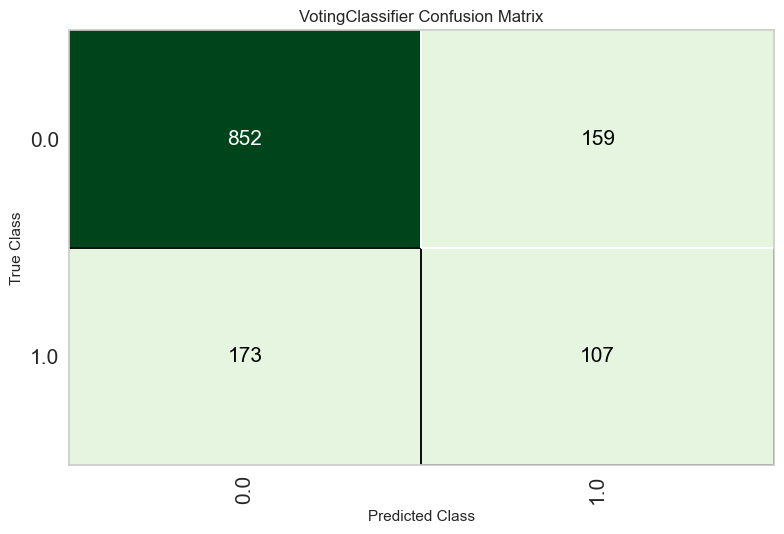

In [38]:
plot_model(mid_cs_tuned, plot='confusion_matrix')

# Yellow cards


## GK


### Base Model


In [9]:
g_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[g_y_features]
g_y_data_tar = g_y_data_tar[g_y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


yellow_cards
0.0    1459
1.0     116
Name: count, dtype: int64


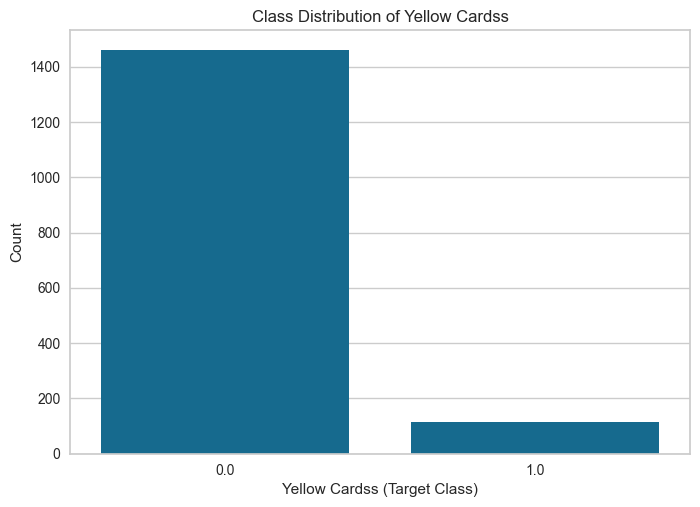

In [10]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

In [ ]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_g_y_model = setup(g_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_y_best = base_g_y_model.compare_models(sort='AUC')
base_g_y_best

[LightGBM] [Info] Number of positive: 1167, number of negative: 1167
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12359
[LightGBM] [Info] Number of data points in the train set: 2334, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,4283
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(2649, 24)"
5,Transformed train set shape,"(2334, 24)"
6,Transformed test set shape,"(315, 24)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.5341,0.5542,0.5378,0.0855,0.1471,0.0227,0.0379,0.6230
rf,Random Forest Classifier,0.9159,0.5379,0.0333,0.1500,0.0508,0.0282,0.0380,0.9600
lr,Logistic Regression,0.6087,0.5357,0.4411,0.0857,0.1431,0.0224,0.0344,2.6930
lda,Linear Discriminant Analysis,0.6254,0.5254,0.3956,0.0808,0.1339,0.0134,0.0212,0.6940
ridge,Ridge Classifier,0.6373,0.5207,0.3756,0.0801,0.1316,0.0119,0.0184,0.6210
dt,Decision Tree Classifier,0.8413,0.5151,0.1322,0.0872,0.1020,0.0200,0.0217,0.5160
xgboost,Extreme Gradient Boosting,0.9151,0.5090,0.0211,0.1250,0.0336,0.0118,0.0214,0.8310
gbc,Gradient Boosting Classifier,0.9167,0.5039,0.0411,0.1667,0.0656,0.0425,0.0550,1.2320
lightgbm,Light Gradient Boosting Machine,0.9214,0.5024,0.0211,0.1500,0.0364,0.0233,0.0369,0.7890
dummy,Dummy Classifier,0.9262,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.7210


SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=4283, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)

In [ ]:
evaluate_model(base_g_y_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

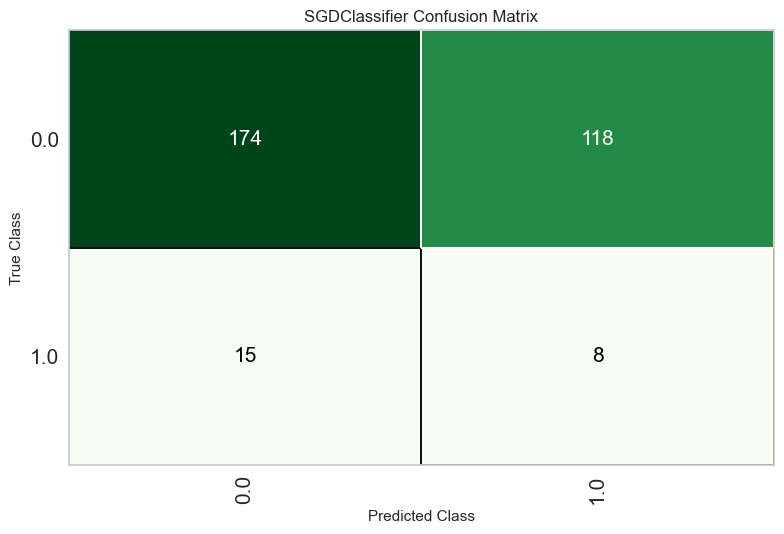

In [ ]:
plot_model(base_g_y_best, plot='confusion_matrix')

### Tuned Model


In [15]:
# Enhanced setup for better performance
tuned_g_y_model = setup(g_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_y_best = tuned_g_y_model.compare_models(n_select=3, sort='F1')
g_y_best

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1575, 116)"
4,Transformed data shape,"(1107, 59)"
5,Transformed train set shape,"(798, 59)"
6,Transformed test set shape,"(315, 59)"
7,Numeric features,114
8,Rows with missing values,6.7%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.6643,0.5725,0.4100,0.0946,0.1529,0.0380,0.0535,0.5290
dt,Decision Tree Classifier,0.7698,0.5450,0.2811,0.0970,0.1433,0.0415,0.0532,0.6940
gbc,Gradient Boosting Classifier,0.8754,0.5351,0.1411,0.1706,0.1410,0.0769,0.0824,0.8750
ada,Ada Boost Classifier,0.8008,0.5225,0.2178,0.1031,0.1373,0.0425,0.0470,0.6810
xgboost,Extreme Gradient Boosting,0.8730,0.5419,0.1189,0.1368,0.1234,0.0570,0.0583,0.4270
knn,K Neighbors Classifier,0.5175,0.4974,0.4533,0.0713,0.1231,-0.0052,-0.0128,0.6440
nb,Naive Bayes,0.2333,0.4839,0.7589,0.0662,0.1212,-0.0143,-0.0301,0.4570
ridge,Ridge Classifier,0.6492,0.5027,0.3111,0.0713,0.1158,-0.0045,-0.0071,0.4860
lr,Logistic Regression,0.6643,0.5072,0.2900,0.0721,0.1151,-0.0038,-0.0076,2.5850
lda,Linear Discriminant Analysis,0.6460,0.4987,0.2911,0.0678,0.1095,-0.0117,-0.0186,0.4170


[SGDClassifier(alpha=0.0001, average=False, class_weight=None,
               early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
               l1_ratio=0.15, learning_rate='optimal', loss='hinge',
               max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
               power_t=0.5, random_state=123, shuffle=True, tol=0.001,
               validation_fraction=0.1, verbose=0, warm_start=False),
 DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                        max_depth=None, max_features=None, max_leaf_nodes=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, random_state=123, splitter='best'),
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max

In [ ]:


# Ensemble (blend or stack)
g_y_blended = blend_models(g_y_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8333,0.0000,0.2222,0.1250,0.1600,0.0755,0.0793
1,0.8492,0.0000,0.4444,0.2222,0.2963,0.2222,0.2390
2,0.8730,0.0000,0.2222,0.1818,0.2000,0.1318,0.1326
3,0.8571,0.0000,0.2222,0.1538,0.1818,0.1064,0.1085
4,0.8571,0.0000,0.1111,0.0909,0.1000,0.0233,0.0234
5,0.8254,0.0000,0.2222,0.1176,0.1538,0.0667,0.0709
6,0.8492,0.0000,0.1111,0.0833,0.0952,0.0148,0.0150
7,0.8016,0.0000,0.1000,0.0588,0.0741,-0.0287,-0.0300
8,0.8571,0.0000,0.2000,0.1667,0.1818,0.1043,0.1048


In [17]:

g_y_tuned = tune_model(g_y_blended, search_library='optuna', optimize='F1')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7381,0.0000,0.1111,0.0385,0.0571,-0.0548,-0.0653
1,0.8016,0.0000,0.5556,0.1923,0.2857,0.2009,0.2393
2,0.8810,0.0000,0.2222,0.2000,0.2105,0.1463,0.1466
3,0.7698,0.0000,0.3333,0.1154,0.1714,0.0731,0.0870
4,0.7698,0.0000,0.2222,0.0833,0.1212,0.0193,0.0224
5,0.7222,0.0000,0.3333,0.0938,0.1463,0.0392,0.0506
6,0.8095,0.0000,0.4444,0.1739,0.2500,0.1642,0.1880
7,0.7619,0.0000,0.0000,0.0000,0.0000,-0.1183,-0.1275
8,0.7540,0.0000,0.2000,0.0800,0.1143,0.0010,0.0012


In [ ]:
plot_model(g_y_tuned, plot='confusion_matrix')

In [22]:
# pcc.plot_model(tuned, plot='threshold')
preds_blend = predict_model(g_y_blended, raw_score=True)

# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_y_tuned, raw_score=True)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.8476,0.5974,0.3043,0.1795,0.2258,0.1475,0.1538


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.7905,0.5465,0.2609,0.1091,0.1538,0.0567,0.0638


In [23]:

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [24]:
evaluate_model(g_y_blended)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [26]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [27]:
g_y_final_model = finalize_model(g_y_blended)
save_model(g_y_final_model, 'g_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                           max_features=None,
        

## Def


### Base Model


In [29]:
d_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[d_y_features]
def_y_data_tar = def_y_data_tar[d_y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

yellow_cards
0.0    5483
1.0     972
Name: count, dtype: int64


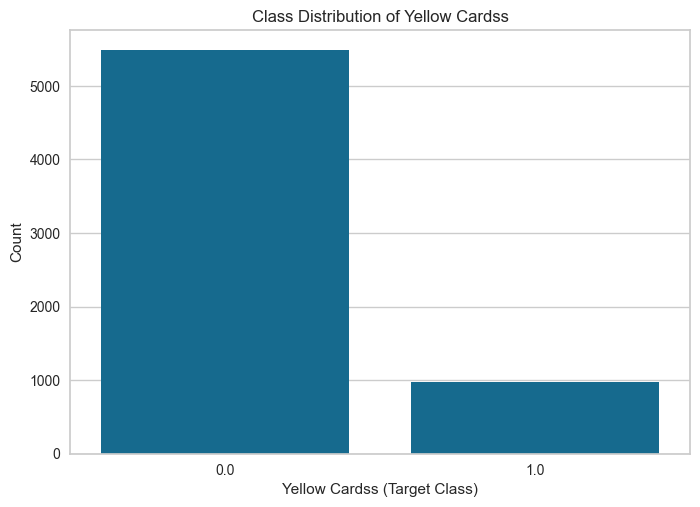

[LightGBM] [Info] Number of positive: 4386, number of negative: 4386
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17754
[LightGBM] [Info] Number of data points in the train set: 8772, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,2626
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(10063, 24)"
5,Transformed train set shape,"(8772, 24)"
6,Transformed test set shape,"(1291, 24)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.4582,0.5404,0.6659,0.1696,0.2703,0.0397,0.0635,1.6960
lr,Logistic Regression,0.5321,0.5470,0.5373,0.1693,0.2572,0.0365,0.0492,2.4170
ridge,Ridge Classifier,0.5347,0.5411,0.5297,0.1683,0.2552,0.0346,0.0468,1.0700
qda,Quadratic Discriminant Analysis,0.5126,0.5371,0.5490,0.1645,0.2530,0.0279,0.0395,1.0810
lda,Linear Discriminant Analysis,0.5302,0.5377,0.5193,0.1647,0.2498,0.0275,0.0370,1.2330
knn,K Neighbors Classifier,0.4649,0.5230,0.5721,0.1550,0.2438,0.0088,0.0129,1.0500
svm,SVM - Linear Kernel,0.4874,0.5020,0.5360,0.1543,0.2384,0.0073,0.0108,1.1170
dt,Decision Tree Classifier,0.7078,0.5050,0.2148,0.1566,0.1807,0.0084,0.0087,1.1390
ada,Ada Boost Classifier,0.8033,0.5295,0.0604,0.1472,0.0760,-0.0061,-0.0057,1.6250
et,Extra Trees Classifier,0.8313,0.5422,0.0360,0.1956,0.0596,0.0126,0.0192,1.8980


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4681,0.5265,0.6410,0.1684,0.2667,0.0364,0.0567
1,0.4584,0.5181,0.6026,0.1588,0.2513,0.0165,0.0256
2,0.4623,0.5401,0.7051,0.1774,0.2835,0.0559,0.0908
3,0.4313,0.4930,0.5513,0.1424,0.2263,-0.0177,-0.0281
4,0.4961,0.5876,0.7051,0.1884,0.2973,0.0771,0.1185
5,0.4612,0.5298,0.6282,0.1644,0.2606,0.0277,0.0433
6,0.4496,0.5353,0.6923,0.1720,0.2755,0.0440,0.0724
7,0.4574,0.5234,0.6410,0.1656,0.2632,0.0301,0.0478
8,0.4283,0.5841,0.7273,0.1697,0.2752,0.0438,0.0765


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [36]:
print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_def_y_model = setup(def_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_y_best = base_def_y_model.compare_models(sort='F1')
base_def_y_best

print('Tuning the model...')
def_y_base_tuned = tune_model(base_def_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

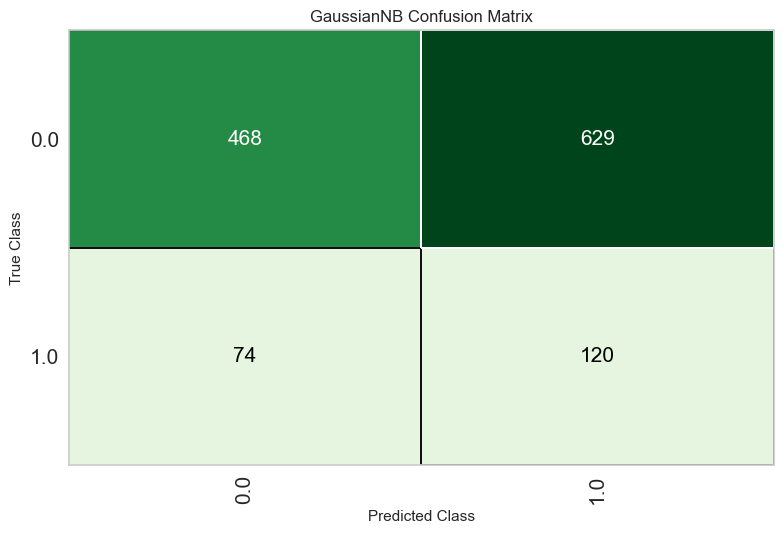

In [ ]:
evaluate_model(base_def_y_best)
plot_model(base_def_y_best, plot='confusion_matrix')

### Blended Model


In [37]:
# Enhanced setup for better performance
tuned_def_y_model = setup(def_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_y_best = tuned_def_y_model.compare_models(n_select=3, sort='F1')
print(def_y_best)

print('Blended model')
# Ensemble (blend or stack)
def_y_blended = blend_models(def_y_best, optimize='F1')

def_y_tuned = tune_model(def_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6455, 116)"
4,Transformed data shape,"(4943, 65)"
5,Transformed train set shape,"(3652, 65)"
6,Transformed test set shape,"(1291, 65)"
7,Numeric features,114
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.3383,0.5204,0.7929,0.1594,0.2654,0.0193,0.0417,0.8020
lda,Linear Discriminant Analysis,0.3542,0.5273,0.7611,0.1583,0.2619,0.0168,0.0348,0.8350
dummy,Dummy Classifier,0.1507,0.5000,1.0000,0.1507,0.2619,0.0000,0.0000,0.6710
nb,Naive Bayes,0.4826,0.5461,0.6067,0.1666,0.2613,0.0325,0.0483,0.9060
ridge,Ridge Classifier,0.3424,0.5221,0.7700,0.1570,0.2608,0.0141,0.0297,0.8500
lr,Logistic Regression,0.3495,0.5264,0.7585,0.1569,0.2600,0.0138,0.0286,0.8490
svm,SVM - Linear Kernel,0.3848,0.5241,0.7109,0.1576,0.2579,0.0151,0.0294,1.0060
qda,Quadratic Discriminant Analysis,0.6354,0.5399,0.3830,0.1779,0.2394,0.0442,0.0496,1.0220
ada,Ada Boost Classifier,0.6861,0.5316,0.2970,0.1777,0.2219,0.0412,0.0433,1.6300
dt,Decision Tree Classifier,0.6472,0.5073,0.3072,0.1582,0.2083,0.0117,0.0122,1.2690


[KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform'), LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001), DummyClassifier(constant=None, random_state=123, strategy='prior')]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.2321,0.4800,0.8590,0.1479,0.2524,-0.0068,-0.0221
1,0.2959,0.5137,0.8590,0.1595,0.2691,0.0196,0.0503
2,0.2650,0.5401,0.9231,0.1614,0.2748,0.0242,0.0740
3,0.2592,0.5309,0.8590,0.1526,0.2592,0.0040,0.0116
4,0.2500,0.5396,0.8333,0.1481,0.2515,-0.0071,-0.0207
5,0.2461,0.4962,0.8077,0.1442,0.2447,-0.0160,-0.0459
6,0.2481,0.5422,0.9744,0.1645,0.2815,0.0308,0.1089
7,0.2616,0.5076,0.8590,0.1533,0.2602,0.0049,0.0142
8,0.2791,0.5254,0.9091,0.1609,0.2734,0.0266,0.0761


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3133,0.4750,0.7308,0.1458,0.2431,-0.0113,-0.0251
1,0.3424,0.5149,0.7436,0.1534,0.2544,0.0057,0.0118
2,0.3153,0.5629,0.8590,0.1634,0.2746,0.0282,0.0686
3,0.3153,0.5216,0.7949,0.1550,0.2594,0.0092,0.0213
4,0.3159,0.5357,0.7949,0.1554,0.2600,0.0095,0.0218
5,0.2946,0.5197,0.7949,0.1512,0.2541,0.0001,0.0003
6,0.2965,0.5324,0.9359,0.1694,0.2868,0.0415,0.1145
7,0.3159,0.4962,0.7949,0.1554,0.2600,0.0095,0.0218
8,0.2965,0.5656,0.8312,0.1546,0.2607,0.0121,0.0303


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Tuned Model


In [ ]:
def_y_tuned = tune_model(def_y_blended, search_library='optuna', optimize='F1')

plot_model(def_y_tuned, plot='confusion_matrix')
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(def_y_tuned, raw_score=True)

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

evaluate_model(def_y_tuned)

## Mid


In [44]:
mid_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[mid_y_features]
mid_y_data_tar = mid_y_data_tar[mid_y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


### Base Model


yellow_cards
0.0    5780
1.0    1057
Name: count, dtype: int64


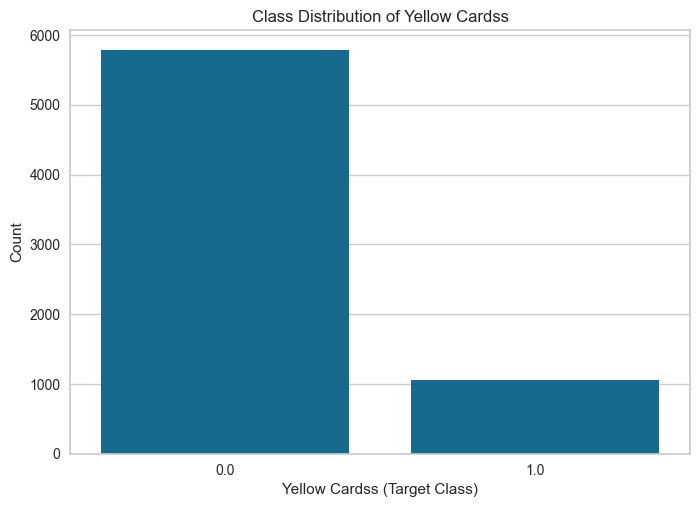

[LightGBM] [Info] Number of positive: 4623, number of negative: 4623
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16785
[LightGBM] [Info] Number of data points in the train set: 9246, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,5752
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6837, 116)"
4,Transformed data shape,"(10614, 24)"
5,Transformed train set shape,"(9246, 24)"
6,Transformed test set shape,"(1368, 24)"
7,Numeric features,114
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5701,0.5917,0.5722,0.1957,0.2916,0.0795,0.1032,1.9630
nb,Naive Bayes,0.4555,0.5824,0.7139,0.1813,0.2890,0.0560,0.0903,3.6680
ridge,Ridge Classifier,0.5683,0.5839,0.5675,0.1937,0.2886,0.0757,0.0988,1.7240
lda,Linear Discriminant Analysis,0.5628,0.5893,0.5568,0.1893,0.2825,0.0672,0.0877,1.0830
qda,Quadratic Discriminant Analysis,0.5379,0.5748,0.5734,0.1835,0.2778,0.0566,0.0760,2.2080
svm,SVM - Linear Kernel,0.5257,0.5635,0.5699,0.1783,0.2707,0.0465,0.0638,1.4770
knn,K Neighbors Classifier,0.4577,0.5216,0.5888,0.1598,0.2514,0.0106,0.0164,1.7750
dt,Decision Tree Classifier,0.7124,0.5033,0.2007,0.1571,0.1759,0.0047,0.0050,1.6660
et,Extra Trees Classifier,0.8157,0.5637,0.0898,0.2487,0.1305,0.0518,0.0613,1.6010
xgboost,Extreme Gradient Boosting,0.8316,0.5617,0.0485,0.2594,0.0808,0.0347,0.0497,1.3180


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5722,0.6099,0.6000,0.2032,0.3036,0.0930,0.1215
1,0.5887,0.6593,0.6000,0.2107,0.3119,0.1064,0.1361
2,0.5612,0.6026,0.5412,0.1862,0.2771,0.0597,0.0772
3,0.5850,0.5477,0.4824,0.1830,0.2654,0.0517,0.0635
4,0.5558,0.5684,0.5529,0.1865,0.2789,0.0606,0.0794
5,0.5704,0.5868,0.6118,0.2047,0.3068,0.0964,0.1268
6,0.5192,0.5982,0.6190,0.1837,0.2834,0.0610,0.0867
7,0.6051,0.6420,0.6190,0.2203,0.3250,0.1273,0.1613
8,0.5503,0.5322,0.5000,0.1707,0.2545,0.0332,0.0430


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [40]:
print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_mid_y_model = setup(mid_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_y_best = base_mid_y_model.compare_models(sort='F1')
base_mid_y_best

print('Tuning the model...')
mid_y_base_tuned = tune_model(base_mid_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

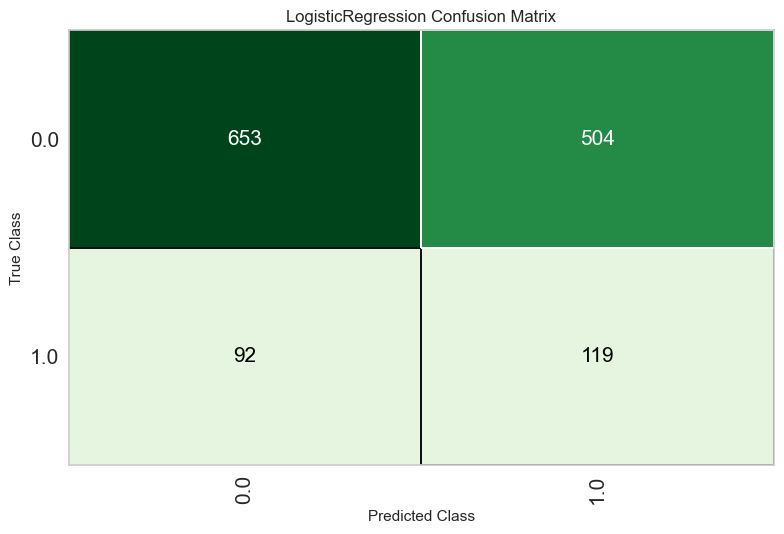

In [41]:
evaluate_model(base_mid_y_best)
plot_model(base_mid_y_best, plot='confusion_matrix')

### Blended Model


In [ ]:
# Enhanced setup for better performance
tuned_mid_y_model = setup(mid_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_y_best = tuned_mid_y_model.compare_models(n_select=3, sort='F1')
print(mid_y_best)

print('Blended model')
# Ensemble (blend or stack)
mid_y_blended = blend_models(mid_y_best, optimize='F1')

mid_y_tuned = tune_model(mid_y_blended, search_library='optuna', optimize='F1')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:11:28
Status,. . . . . . . . . . . . . . . . . .,Finalizing Model
Estimator,. . . . . . . . . . . . . . . . . .,Voting Classifier


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

ValueError: cannot set WRITEABLE flag to True of this array

### Tuned Model


In [ ]:
mid_y_tuned = tune_model(mid_y_blended, search_library='optuna', optimize='F1')

plot_model(mid_y_tuned, plot='confusion_matrix')
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(mid_y_tuned, raw_score=True)

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

evaluate_model(mid_y_tuned)

## FWD


In [ ]:
fwd_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home',  'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[fwd_y_features]
fwd_y_data_tar = fwd_y_data_tar[fwd_y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

,Description,Value
0,Session id,6189
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1519, 116)"
4,Transformed data shape,"(1519, 116)"
5,Transformed train set shape,"(1063, 116)"
6,Transformed test set shape,"(456, 116)"
7,Numeric features,114
8,Rows with missing values,3.4%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8805,0.5580,0.0000,0.0000,0.0000,0.0000,0.0000,0.5200
dummy,Dummy Classifier,0.8805,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1370
lr,Logistic Regression,0.8796,0.5022,0.0000,0.0000,0.0000,-0.0018,-0.0036,3.5200
ridge,Ridge Classifier,0.8796,0.5366,0.0077,0.1000,0.0143,0.0092,0.0188,0.1700
et,Extra Trees Classifier,0.8796,0.5639,0.0000,0.0000,0.0000,-0.0018,-0.0036,0.3460
lightgbm,Light Gradient Boosting Machine,0.8777,0.5679,0.0000,0.0000,0.0000,-0.0053,-0.0109,0.8780
xgboost,Extreme Gradient Boosting,0.8749,0.5412,0.0077,0.1000,0.0143,0.0011,0.0077,0.4140
knn,K Neighbors Classifier,0.8730,0.5583,0.0160,0.1000,0.0276,0.0082,0.0103,0.1440
gbc,Gradient Boosting Classifier,0.8730,0.5199,0.0083,0.0250,0.0125,-0.0034,-0.0129,1.2840
qda,Quadratic Discriminant Analysis,0.8626,0.5046,0.0077,0.0333,0.0125,-0.0193,-0.0270,0.1010


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=6189, verbose=0,
                       warm_start=False)

### Base Model


In [ ]:
print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_fwd_y_model = setup(fwd_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_fwd_y_best = base_fwd_y_model.compare_models(sort='F1')
base_fwd_y_best

print('Tuning the model...')
fwd_y_base_tuned = tune_model(base_fwd_y_best, search_library='optuna', optimize='F1')

In [ ]:
evaluate_model(base_def_y_best)
plot_model(base_def_y_best, plot='confusion_matrix')

### Blended Model


In [ ]:
# Enhanced setup for better performance
tuned_fwd_y_model = setup(fwd_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

fwd_y_best = tuned_fwd_y_model.compare_models(n_select=3, sort='F1')
print(fwd_y_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_y_blended = blend_models(fwd_y_best, optimize='F1')

fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

### Tuned Model


In [ ]:
fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

plot_model(fwd_y_tuned, plot='confusion_matrix')
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(fwd_y_tuned, raw_score=True)

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

evaluate_model(fwd_y_tuned)